# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Rayhan Lutfi Hakim | 5054251043 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [54]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns   
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [55]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Jumlah baris dan kolom:", df.shape)
print("Tipe data: ", df.dtypes)
df.describe()
print("Jumlah missing value: ", df.isnull().sum().sum())

Jumlah baris dan kolom: (7043, 21)
Tipe data:  customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Jumlah missing value:  0


C:\Users\M S I\AppData\Local\Temp\ipykernel_10728\1053424477.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


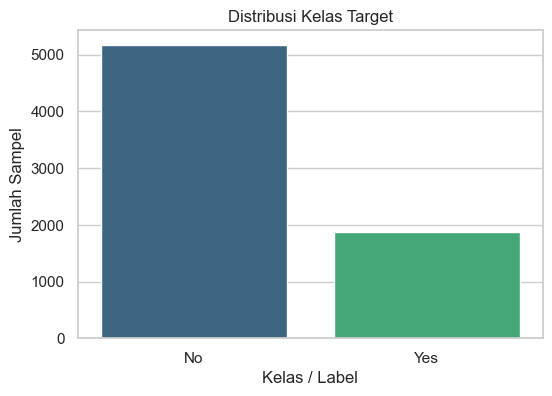

Jumlah sampel per kelas:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase per kelas:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [56]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
# Ganti 'target_column' dengan nama kolom target/label di dataset Anda
sns.countplot(x='Churn', data=df, palette='viridis') 

plt.title('Distribusi Kelas Target')
plt.xlabel('Kelas / Label')
plt.ylabel('Jumlah Sampel')
plt.show()

# 2. Memeriksa jumlah dan persentase secara numerik
print("Jumlah sampel per kelas:")
print(df['Churn'].value_counts())

print("\nPersentase per kelas:")
print(df['Churn'].value_counts(normalize=True) * 100)

7 Fitur dengan korelasi terkuat terhadap target:
1. tenure (Nilai Korelasi Absolut: 0.3522)
2. MonthlyCharges (Nilai Korelasi Absolut: 0.1934)
3. SeniorCitizen (Nilai Korelasi Absolut: 0.1509)


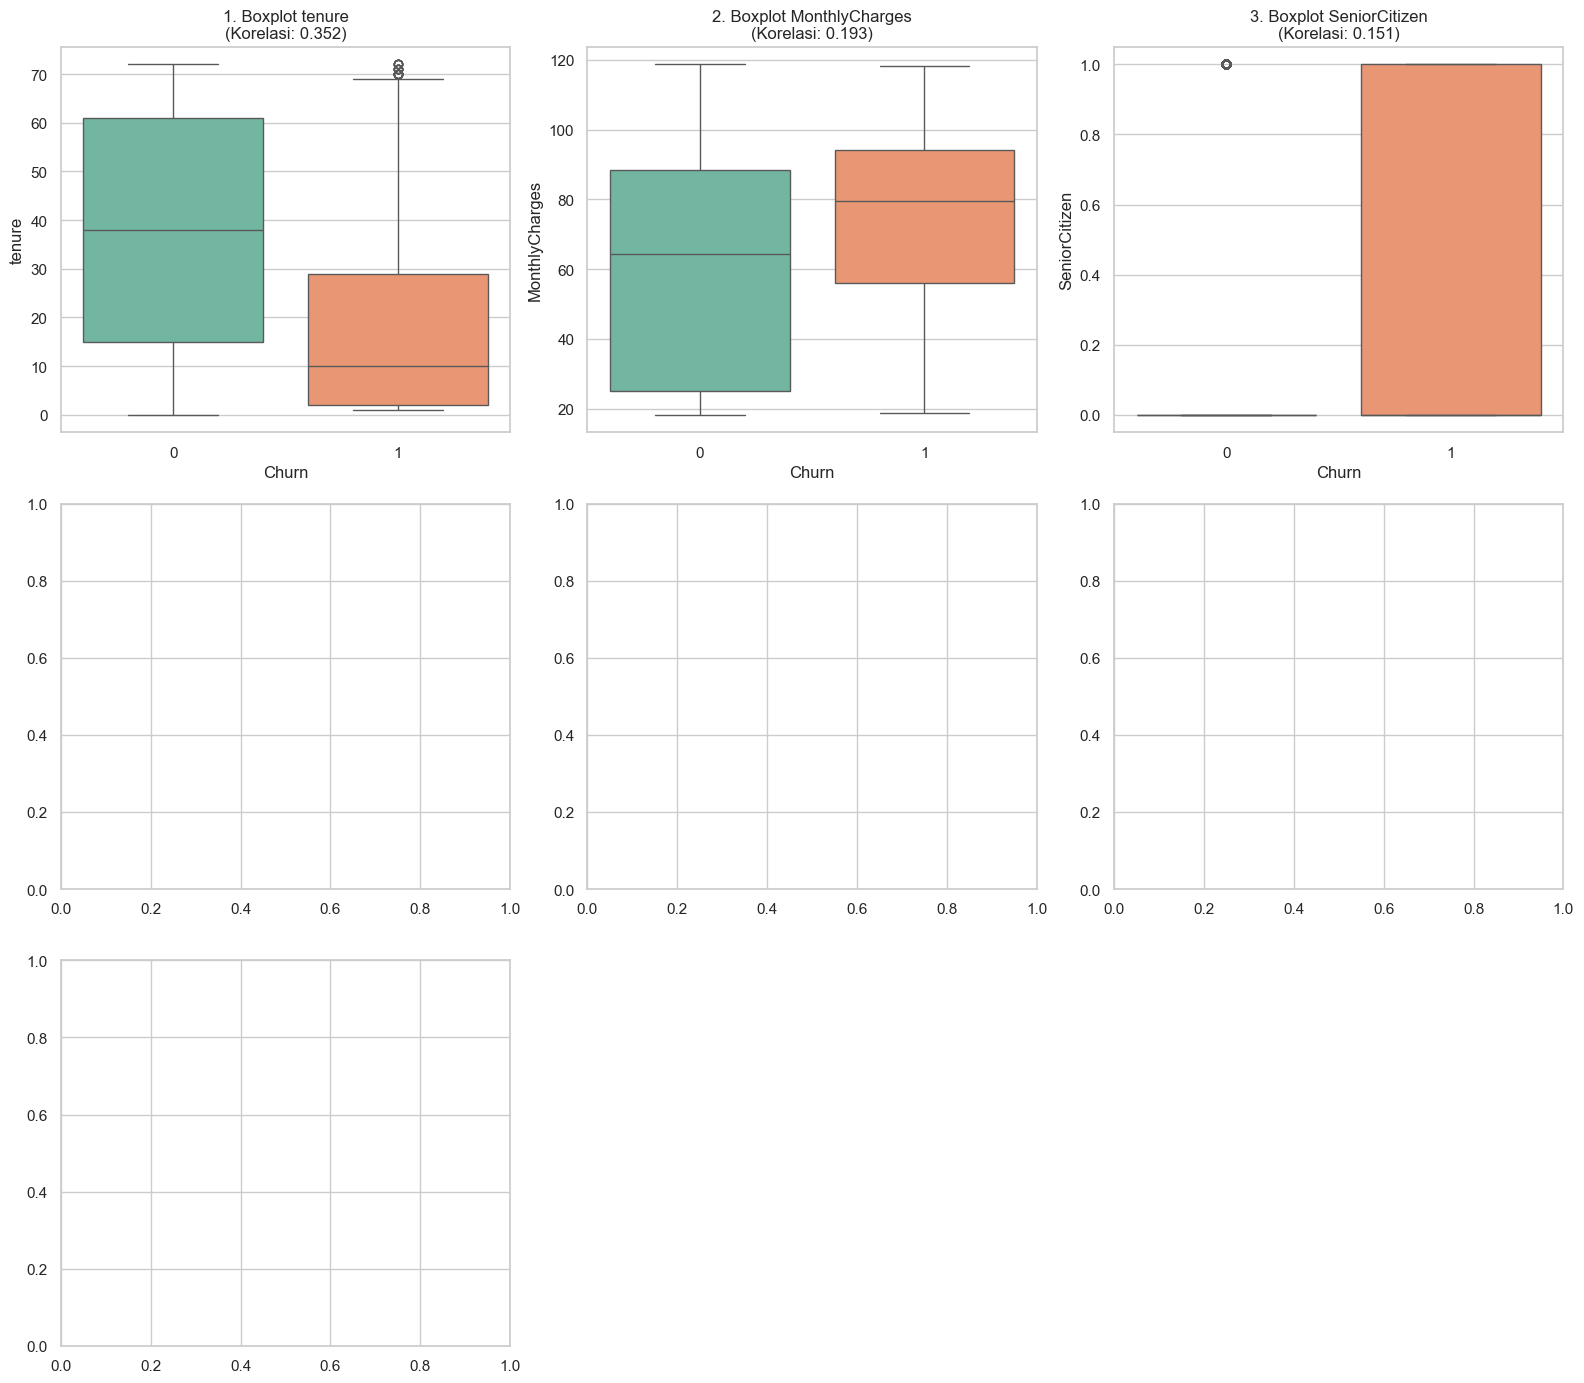

In [57]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
korelasi = df.corr(numeric_only=True)['Churn'].abs()
korelasi = korelasi.drop(labels=['Churn'])
top_7_fitur = korelasi.nlargest(7).index.tolist()

print("7 Fitur dengan korelasi terkuat terhadap target:")
for rank, feat in enumerate(top_7_fitur, 1):
    print(f"{rank}. {feat} (Nilai Korelasi Absolut: {korelasi[feat]:.4f})")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, fitur in enumerate(top_7_fitur):
    sns.boxplot(
        data=df,
        x='Churn',  
        y=fitur,  
        hue='Churn',
        palette="Set2",
        ax=axes[i],
        legend=False,
    )
    axes[i].set_title(f"{i+1}. Boxplot {fitur}\n(Korelasi: {korelasi[fitur]:.3f})")
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(fitur)

fig.delaxes(axes[-1])
fig.delaxes(axes[-2])

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [58]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop(columns=['customerID'])

In [59]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
X = df.drop(columns=['Churn'])
y = df['Churn']

kategorikal = X.select_dtypes(include=['object']).columns.tolist()
X = pd.get_dummies(X, columns=kategorikal, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

C:\Users\M S I\AppData\Local\Temp\ipykernel_10728\2723623127.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategorikal = X.select_dtypes(include=['object']).columns.tolist()


In [60]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [61]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [62]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),   
    activation='relu',          
    solver='adam',              
    max_iter=500,               
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

In [63]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_baseline = y_pred.copy()

print("Contoh 10 prediksi pertama:", y_pred_baseline[:10])
print("Distribusi prediksi:\n", pd.Series(y_pred_baseline).value_counts())

Contoh 10 prediksi pertama: [0 1 0 0 0 1 1 0 0 0]
Distribusi prediksi:
 0    1081
1     328
Name: count, dtype: int64


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [64]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.
aktivasi_list = ['relu', 'tanh', 'logistic']
model_aktivasi = {}
y_pred_aktivasi = {}

for act in aktivasi_list:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    model_aktivasi[act] = model
    y_pred_aktivasi[act] = model.predict(X_test_scaled)

In [65]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
data_akurasi = []

for act in aktivasi_list:
    acc = accuracy_score(y_test, y_pred_aktivasi[act])
    data_akurasi.append({
        'Fungsi Aktivasi': 'Sigmoid (Logistic)' if act == 'logistic' else act.upper(),
        'Akurasi Test Set': f"{acc * 100:.2f}%"
    })

# Tampilkan tabel perbandingan
df_akurasi = pd.DataFrame(data_akurasi)
display(df_akurasi)

,Fungsi Aktivasi,Akurasi Test Set
0,RELU,79.13%
1,TANH,79.56%
2,Sigmoid (Logistic),79.28%


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [66]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.
best_activation = 'tanh'  # Ganti dengan 'tanh' atau 'logistic' jika hasil 3.2 Anda berbeda

# Variasi arsitektur hidden layer
hidden_layer_list = [(2,), (5,), (10,), (50,), (100, 50)]

model_layer = {}
y_pred_layer = {}
results_layer = []

for layers in hidden_layer_list:
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation=best_activation,
        solver='adam',
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    
    # Simpan model dan hasil prediksi
    model_layer[layers] = model
    y_pred = model.predict(X_test_scaled)
    y_pred_layer[layers] = y_pred

d:\miniconda\envs\satria_data\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [67]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc_list = []
test_acc_list = []
arch_labels = [str(layers) for layers in hidden_layer_list]

# Hitung akurasi train set dan test set untuk setiap arsitektur
for layers in hidden_layer_list:
    model = model_layer[layers]
    
    # Prediksi
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Hitung akurasi
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # Simpan ke list
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

# Cek hasil perhitungan singkat
print("Label Arsitektur :", arch_labels)
print("Akurasi Train    :", [round(acc, 4) for acc in train_acc_list])
print("Akurasi Test     :", [round(acc, 4) for acc in test_acc_list])

Label Arsitektur : ['(2,)', '(5,)', '(10,)', '(50,)', '(100, 50)']
Akurasi Train    : [0.8058, 0.811, 0.8266, 0.896, 0.9611]
Akurasi Test     : [0.7949, 0.7906, 0.7956, 0.7502, 0.7445]


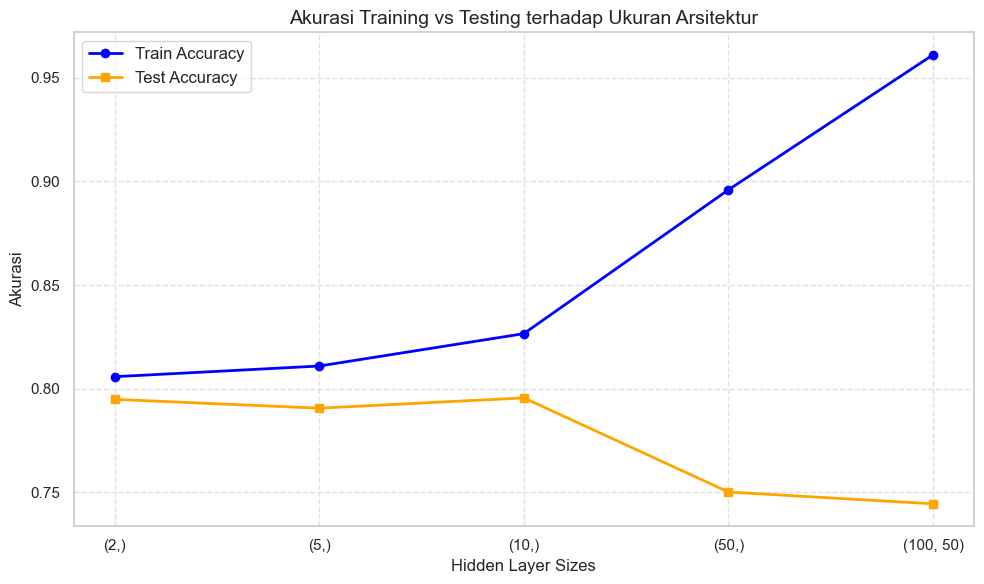

In [68]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(10, 6))

plt.plot(arch_labels, train_acc_list, marker='o', label='Train Accuracy', color='blue', linewidth=2)
plt.plot(arch_labels, test_acc_list, marker='s', label='Test Accuracy', color='orange', linewidth=2)

plt.title('Akurasi Training vs Testing terhadap Ukuran Arsitektur', fontsize=14)
plt.xlabel('Hidden Layer Sizes', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [69]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

best_act_key = max(model_aktivasi, key=lambda k: accuracy_score(y_test, model_aktivasi[k].predict(X_test_scaled)))
best_model_32 = model_aktivasi[best_act_key]

best_layer_key = max(model_layer, key=lambda k: accuracy_score(y_test, model_layer[k].predict(X_test_scaled)))
best_model_33 = model_layer[best_layer_key]

def calc_metrics(model, exp_name):
    y_pred = model.predict(X_test_scaled)
    return {
        'Eksperimen Model': exp_name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    }
eval_results = [
    calc_metrics(best_model_32, f"Exp 3.2 Best ({best_act_key.upper()})"),
    calc_metrics(best_model_33, f"Exp 3.3 Best ({best_layer_key})")
]

acc_32 = accuracy_score(y_test, best_model_32.predict(X_test_scaled))
acc_33 = accuracy_score(y_test, best_model_33.predict(X_test_scaled))

if acc_33 >= acc_32:
    best_overall_model = best_model_33
    best_overall_name = f"Exp 3.3 Arsitektur {best_layer_key}"
else:
    best_overall_model = best_model_32
    best_overall_name = f"Exp 3.2 Aktivasi {best_act_key}"

df_evaluasi = pd.DataFrame(eval_results)
display(df_evaluasi)

,Eksperimen Model,Accuracy,Precision,Recall,F1-Score
0,Exp 3.2 Best (TANH),0.7956,0.6352,0.5401,0.5838
1,"Exp 3.3 Best ((10,))",0.7956,0.6352,0.5401,0.5838


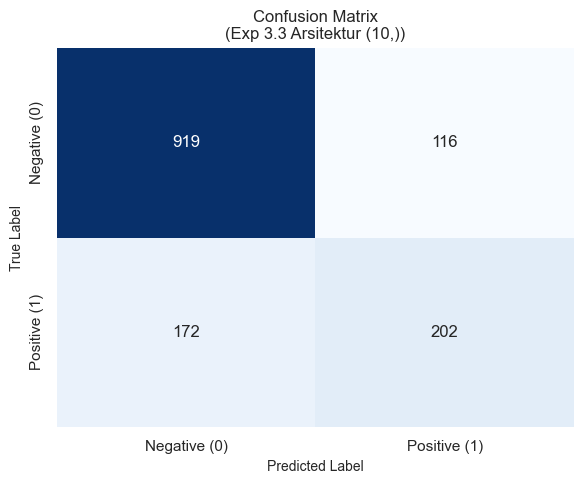

In [70]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.
y_pred_best = best_overall_model.predict(X_test_scaled)

# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot Heatmap Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])

plt.title(f'Confusion Matrix\n({best_overall_name})', fontsize=12)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

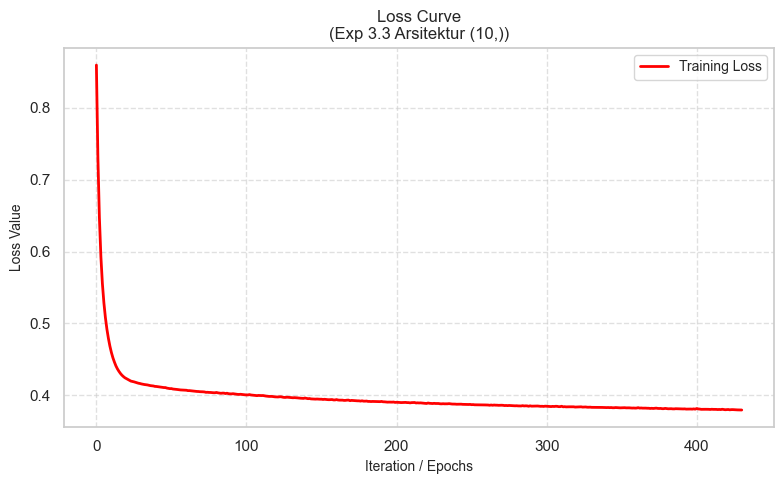

In [71]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.

plt.figure(figsize=(8, 5))
plt.plot(best_overall_model.loss_curve_, color='red', linewidth=2, label='Training Loss')

plt.title(f'Loss Curve\n({best_overall_name})', fontsize=12)
plt.xlabel('Iteration / Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

1. Tidak berbeda jauh hasilnya, hal itu bisa jadi dikarenakan mereka menggunakan data yang sudah discaler dengan cara yang sama.
2. (50,) mulai menunjukkan tanda tanda overfitting terlihat dari grafik test yang turun tjam dikarenakan neuron yang terlalu besar
3. Sudah, jika loss curve masih menurun tajam saat max_iter tercapai maka saya akan menaikkan max_iter


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan yang bisa didapat adalah hasil sekarang masih belum maksimum, oleh karena itu untuk memaksimalkan bisa melakukan balancing data dulu dan mencoba RandomizedSearchCV karena pada notebook ini menggunakan MLPClassifier 